# STEP 0. 환경설정
- 처음 실행시
- 모델 학습 중간에 커널이 죽었을 경우 재실행
  

In [1]:
# 한글 폰트 설정은 한번 실행하고 런타임 재시작을 해야합니다
import platform
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [14]:
# 학습용 데이터 로드

import pickle

with open('preprocessed/data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_val = data['X_val']
y_train = data['y_train']
y_val = data['y_val']
X_train_texts = data['X_train_texts']
X_val_texts = data['X_val_texts']

In [15]:
# 라이브러리 로드
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
from konlpy.tag import Okt
from collections import Counter
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.16.2


# STEP 1. 데이터 가져오기

- 캐글페이지에서 학습데이터를 가져옵시다~ https://www.kaggle.com/competitions/deep-learning-main-quest-dktc-ds-8/data

- 본인의 경로로 바꿔줍시다

In [16]:
# 기존 train 데이터 로드
train_data_path = "data/train.csv"
train_data = pd.read_csv(train_data_path)

# normal_conversation 데이터 로드
normal_data_path = "data/normal_conversation.csv"
normal_data = pd.read_csv(normal_data_path)

# normal_data에 idx 컬럼 추가 (train_data의 마지막 idx부터 이어서)
normal_data['idx'] = range(train_data['idx'].max() + 1,
                           train_data['idx'].max() + 1 + len(normal_data))

# 컬럼 순서를 train_data와 동일하게 맞추기 (idx, class, conversation)
normal_data = normal_data[['idx', 'class', 'conversation']]

# 두 데이터프레임 합치기
train_data = pd.concat([train_data, normal_data], ignore_index=True)

print("합친 후 데이터 shape:", train_data.shape)
print("\n클래스 분포:")
print(train_data['class'].value_counts())
print("\n처음 5개 행:")
print(train_data.head())
print("\n마지막 5개 행:")
print(train_data.tail())

합친 후 데이터 shape: (5216, 3)

클래스 분포:
class
일반 대화          1266
기타 괴롭힘 대화      1094
갈취 대화           981
직장 내 괴롭힘 대화     979
협박 대화           896
Name: count, dtype: int64

처음 5개 행:
   idx      class                                       conversation
0    0      협박 대화  지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 ...
1    1      협박 대화  길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 ...
2    2  기타 괴롭힘 대화  너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미...
3    3      갈취 대화  어이 거기\n예??\n너 말이야 너. 이리 오라고\n무슨 일.\n너 옷 좋아보인다?...
4    4      갈취 대화  저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...

마지막 5개 행:
       idx  class                                       conversation
5211  5211  일반 대화  최근에 어떤 앱을 자주 사용해? 나는 운동 기록 앱을 사용하고 있어. 매일 운동극한...
5212  5212  일반 대화  을 사려고 하는데 추천 수 있나요?최근에 출시된 A모델이 좋다고 들었어요.감사합니다...
5213  5213  일반 대화  새 전자제품을 사려고 하는데 추천해주실 수 있나요? 최근에 출시된 A모델이 좋다고 ...
5214  5214  일반 대화  이번 주말에 친구들들신난다함께스릴 에 가기로 했어.타고정말 기대돼!많이놀이기구를 타...
5215  5215  일반 대화  이번 주말에 친구들과 함께 놀이공원에 가기로 했어. 정말 기대

### 전처리!

- 영어와조금은 다른 전처리를 해줘야합니다
- 또 어떤 부분이 다를까요?
- 일단 기본적으로 한국어 영어 특수한 부분은 남기고 없애줍시다
- 긴 공백도 없애줍시다

- 실제 데이터를 살펴보면서 전처리를 해줘야하는것들을 찾아주면 좋습니다

### 토큰화

- 영어는 띄어쓰기를 기준으로 토큰화를 진행합니다
- 한글은 형태소를 기준으로 토큰화를 진행합니다Okt 라는 라이브러리를 이용합니다

In [17]:
# 전처리 함수
def clean_korean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^가-힣a-zA-Z0-9\\s.,!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 토큰화 함수
tokenizer_okt = Okt()

def tokenize_korean(text):
    if not isinstance(text, str) or len(text) == 0:
        return []
    try:
        return tokenizer_okt.morphs(text)
    except:
        return []

# 전처리 및 토큰화 적용
print("전처리 및 토큰화 진행 중...")
train_data['cleaned_text'] = train_data['conversation'].apply(clean_korean_text)
train_data['tokens'] = train_data['cleaned_text'].apply(tokenize_korean)
train_data['token_length'] = train_data['tokens'].apply(len)

corpus = train_data['tokens']

print("완료!")

전처리 및 토큰화 진행 중...
완료!


### 토큰화가 어떻게 진행되었는지를 확인해봅시다

In [18]:
train_data

,idx,class,conversation,cleaned_text,tokens,token_length
0,0,협박 대화,지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 ...,지금 너 스스로를 죽여달라고 애원하는 것인가? 아닙니다. 죄송합니다. 죽을 거면 혼...,"[지금, 너, 스스로, 를, 죽여, 달라, 고, 애원, 하는, 것, 인가, ?, 아...",99
1,1,협박 대화,길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 ...,길동경찰서입니다. 9시 40분 마트에 폭발물을 설치할거다. 네? 똑바로 들어 한번만...,"[길동, 경찰서, 입니다, ., 9시, 40분, 마트, 에, 폭발물, 을, 설치, ...",73
2,2,기타 괴롭힘 대화,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미...,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어. 그만해. 니들 놀리는거 재미없...,"[너, 되게, 귀여운거, 알, 지, ?, 나, 보다, 작은, 남자, 는, 첨, 봤어...",97
3,3,갈취 대화,어이 거기\n예??\n너 말이야 너. 이리 오라고\n무슨 일.\n너 옷 좋아보인다?...,어이 거기 예?? 너 말이야 너. 이리 오라고 무슨 일. 너 옷 좋아보인다? 얘 돈...,"[어이, 거기, 예, ??, 너, 말, 이야, 너, ., 이리, 오라, 고, 무슨,...",48
4,4,갈취 대화,저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...,저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...,"[저기, 요, 혹시, 날, 이, 너무, 뜨겁잖아요, ?, 저희, 회사, 에서, 이,...",186
...,...,...,...,...,...,...
5211,5211,일반 대화,최근에 어떤 앱을 자주 사용해? 나는 운동 기록 앱을 사용하고 있어. 매일 운동극한...,최근에 어떤 앱을 자주 사용해? 나는 운동 기록 앱을 사용하고 있어. 매일 운동극한...,"[최근, 에, 어떤, 앱, 을, 자주, 사용, 해, ?, 나, 는, 운동, 기록, ...",60
5212,5212,일반 대화,을 사려고 하는데 추천 수 있나요?최근에 출시된 A모델이 좋다고 들었어요.감사합니다...,을 사려고 하는데 추천 수 있나요?최근에 출시된 A모델이 좋다고 들었어요.감사합니다...,"[을, 사려, 고, 하는데, 추천, 수, 있나요, ?, 최근, 에, 출시, 된, A...",55
5213,5213,일반 대화,새 전자제품을 사려고 하는데 추천해주실 수 있나요? 최근에 출시된 A모델이 좋다고 ...,새 전자제품을 사려고 하는데 추천해주실 수 있나요? 최근에 출시된 A모델이 좋다고 ...,"[새, 전자제품, 을, 사려, 고, 하는데, 추천, 해주실, 수, 있나요, ?, 최...",72
5214,5214,일반 대화,이번 주말에 친구들들신난다함께스릴 에 가기로 했어.타고정말 기대돼!많이놀이기구를 타...,이번 주말에 친구들들신난다함께스릴 에 가기로 했어.타고정말 기대돼!많이놀이기구를 타...,"[이번, 주말, 에, 친구, 들들, 신난다, 함께, 스릴, 에, 가기, 로, 했어,...",68


### 시퀀스 길이를 조절해보자

- 너무 긴 시퀀스가 중간중간 섞여있으면 그 친구를 기준으로 전체 길이가 정해짐
- 짧은 문장들은 뒤에가 다 0인채로 모델에 학습됨
- 이는 성능 저하를 불러올수도있기 때문에 조금 잘라냄

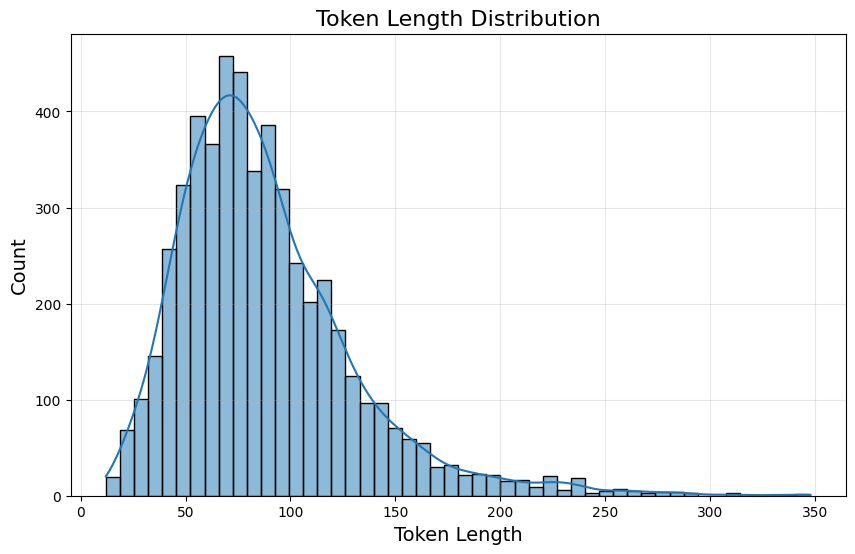

1사분위수 (Q1): 59.0
2사분위수 (Q2, Median): 80.0
3사분위수 (Q3): 109.0
최대 길이: 348


In [19]:
# 1) 히스토그램 시각화
plt.figure(figsize=(10,6))
sns.histplot(train_data['token_length'], bins=50, kde=True)
plt.title("Token Length Distribution", fontsize=16)
plt.xlabel("Token Length", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# 2) 사분위수 계산
q1 = train_data['token_length'].quantile(0.25)
q2 = train_data['token_length'].quantile(0.50)  # median
q3 = train_data['token_length'].quantile(0.75)
max_len = train_data['token_length'].max()

# 3) 출력
print(f"1사분위수 (Q1): {q1}")
print(f"2사분위수 (Q2, Median): {q2}")
print(f"3사분위수 (Q3): {q3}")
print(f"최대 길이: {max_len}")

### Voca 만들기

- 크기는 10000개 정도로 잡아줍시다
- 크기를 바꾸면서 성능을 보셔도 좋습니다
- 저번에는 영어였고 이번에는 한글 단어장이라 숫자가 달라질수도..?

In [23]:
def tokenize(corpus):
    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        num_words=10000,
        filters=' ',
        oov_token="<unk>"
    )
    tokenizer.fit_on_texts(corpus)
    tensor = tokenizer.texts_to_sequences(corpus)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post',maxlen=150)

    print(tensor,tokenizer)
    return tensor, tokenizer

tensor, tokenizer = tokenize(corpus)

[[  40    7 2802 ...    0    0    0]
 [ 447 1796  202 ...    0    0    0]
 [   7  943    1 ...    0    0    0]
 ...
 [ 720 6533   15 ...    0    0    0]
 [  62   99    6 ...    0    0    0]
 [  62   99    6 ...    0    0    0]] <keras.src.legacy.preprocessing.text.Tokenizer object at 0x35010e1d0>


In [24]:
import os
import pickle

os.makedirs('artifacts', exist_ok=True)

with open('artifacts/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print(type(tokenizer))
print('저장 완료: artifacts/lstm_tokenizer.pkl')

<class 'keras.src.legacy.preprocessing.text.Tokenizer'>
저장 완료: artifacts/lstm_tokenizer.pkl


### class 처리 및 분할

- class가 object 타입 즉 '협박' 이런식으로 작성되어있기때문에
- 이를 정수형으로 변환할 필요가있음 (순서주의, 캐글에서는 제출숫자와 자동 매핑 숫자를 구분해야함)
- 이후 적당한 퍼센트를 val, test로 나눔
- 각 라벨별 비율이 극단적으로 나뉘지는 않았는지를 확인

In [7]:
from sklearn.preprocessing import LabelEncoder

X = tensor


# 각 클래스를 숫자로 매핑
label_map = {
    '협박 대화': 0,
    '갈취 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '기타 괴롭힘 대화': 3,
    '일반 대화': 4
}

y = train_data['class'].map(label_map)

y = np.array(y)

print("X shape:", X.shape)  # (num_samples, 150)
print("y shape:", y.shape)  # (num_samples,)


idx = np.arange(len(X))

train_idx, val_idx = train_test_split(
    idx,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 1차 LSTM
X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

# 2차 Transformer
texts = train_data['cleaned_text'].tolist()
X_train_texts = [texts[i] for i in train_idx]
X_val_texts = [texts[i] for i in val_idx]

# 학습용데이터 저장
import pickle
import os

os.makedirs('preprocessed', exist_ok=True)

with open('preprocessed/data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_val': X_val,
        'y_train': y_train,
        'y_val': y_val,
        'X_train_texts': X_train_texts,
        'X_val_texts': X_val_texts
    }, f)

# 클래스 분포 확인
print("\n클래스 분포:")
print("Train:", np.bincount(y_train))
print("Validation:", np.bincount(y_val))

X shape: (5216, 150)
y shape: (5216,)

클래스 분포:
Train: [ 761  834  832  930 1076]
Validation: [135 147 147 164 190]


# Step 2. LSTM 기반 모델 비교
- 하이퍼파라미터를 고정하고 모델별 성능을 비교
- 가장 좋은 모델 1개를 선정
- 비교 모델
1. BILSTM
2. BIGRU
3. TextCNN
4. CNN + BIGRU

In [8]:
# 1. 재현성 고정
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [10]:
# 2. 공통 학슬 설정

# 2-1. 하이퍼파라미터 설정
BATCH_SIZE = 32
EPOCHS = 20
VOCAB_SIZE = tokenizer.num_words
EMBEDDING_DIM = 128
MAX_LENGTH = 150
NUM_CLASSES = len(np.unique(y))

print('모델 하이퍼파라미터:')
print(f"Vocab Size: {VOCAB_SIZE}")
print(f"Embedding Dim: {EMBEDDING_DIM}")
print(f"Max Length: {MAX_LENGTH}")
print(f"Num Classes: {NUM_CLASSES}")

# 2-2. 콜백 (얼리스타핑, 학습률조정)
common_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

모델 하이퍼파라미터:
Vocab Size: 10000
Embedding Dim: 128
Max Length: 150
Num Classes: 5


In [10]:
# 3. 모델 정의
def build_bilstm_model(vocab_size, embedding_dim, max_length, num_classes):
    model = keras.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_length,
            mask_zero=True
        ),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_bigru_model(vocab_size, embedding_dim, max_length, num_classes):
    model = keras.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_length,
            mask_zero=True
        ),
        layers.Bidirectional(layers.GRU(128, return_sequences=True)),
        layers.Bidirectional(layers.GRU(64)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_textcnn_model(vocab_size, embedding_dim, max_length, num_classes):
    inputs = keras.Input(shape=(max_length,))
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )(inputs)

    x1 = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x1 = layers.GlobalMaxPooling1D()(x1)

    x2 = layers.Conv1D(128, 4, activation='relu', padding='same')(x)
    x2 = layers.GlobalMaxPooling1D()(x2)

    x3 = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
    x3 = layers.GlobalMaxPooling1D()(x3)

    x = layers.Concatenate()([x1, x2, x3])
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_cnn_bigru_model(vocab_size, embedding_dim, max_length, num_classes):
    inputs = keras.Input(shape=(max_length,))
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length,
        mask_zero=False
    )(inputs)

    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Bidirectional(layers.GRU(64))(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 모델 딕셔너리
model_builders = {
    'BiLSTM': build_bilstm_model,
    'BiGRU': build_bigru_model,
    'TextCNN': build_textcnn_model,
    'CNN_BiGRU': build_cnn_bigru_model
}

In [ ]:
import pickle
import os

SAVE_DIR = 'saved_LSTMs'
os.makedirs(SAVE_DIR, exist_ok=True)

results = []
histories = {}

for model_name, build_fn in model_builders.items():
    print(f'\n===== {model_name} 학습 시작 =====')

    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = build_fn(VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH, NUM_CLASSES)

    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=common_callbacks,
        verbose=1
    )

    train_time = time.time() - start_time

    model.save(f'{SAVE_DIR}/{model_name}.keras')

    with open(f'{SAVE_DIR}/{model_name}_history.pkl', 'wb') as f:
        pickle.dump(history.history, f)

    y_pred_prob = model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    val_acc = accuracy_score(y_val, y_pred)
    val_macro_f1 = f1_score(y_val, y_pred, average='macro')
    best_val_loss = min(history.history['val_loss'])
    best_val_acc = max(history.history['val_accuracy'])

    results.append({
        'model': model_name,
        'val_accuracy': val_acc,
        'val_macro_f1': val_macro_f1,
        'best_val_loss': best_val_loss,
        'best_val_accuracy_from_history': best_val_acc,
        'epochs_ran': len(history.history['loss']),
        'train_time_sec': train_time
    })

    histories[model_name] = history.history

    pd.DataFrame(results).to_csv(f'{SAVE_DIR}/results1.csv', index=False)

    print(f'{model_name} 완료')
    print(f'val_accuracy: {val_acc:.4f}')
    print(f'val_macro_f1: {val_macro_f1:.4f}')
    print(f'best_val_loss: {best_val_loss:.4f}')
    print(f'train_time_sec: {train_time:.2f}')

In [12]:
results_df = pd.DataFrame(results).sort_values(
    by=['val_macro_f1', 'val_accuracy'],
    ascending=False
).reset_index(drop=True)

results_df

,model,val_accuracy,val_macro_f1,best_val_loss,best_val_accuracy_from_history,epochs_ran,train_time_sec
0,TextCNN,0.876117,0.868170,0.342657,0.882503,6,12.560203
1,BiLSTM,0.726692,0.710737,0.761571,0.777778,15,283.900810
2,CNN_BiGRU,0.727969,0.706943,0.519131,0.840358,3,19.384192
3,BiGRU,0.223499,0.115489,1.228017,0.388250,3,59.952249


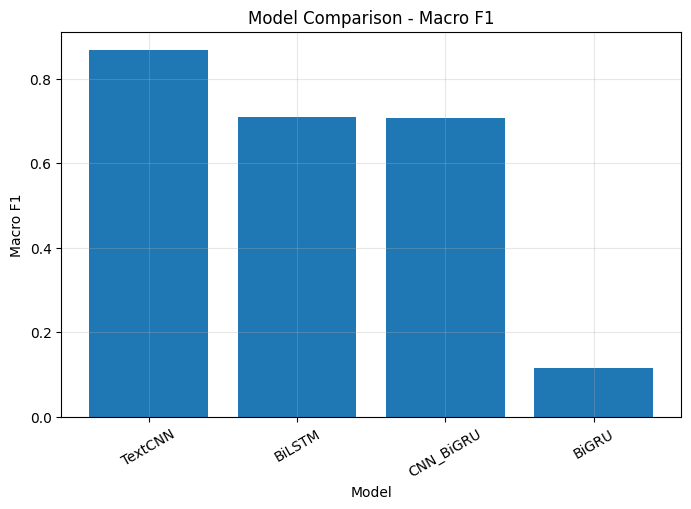

In [13]:
# 5-1. f1 비교

plt.figure(figsize=(8,5))

df_plot = results_df.sort_values(by='val_macro_f1', ascending=False)

plt.bar(df_plot['model'], df_plot['val_macro_f1'])
plt.title('Model Comparison - Macro F1')
plt.xlabel('Model')
plt.ylabel('Macro F1')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)

plt.show()

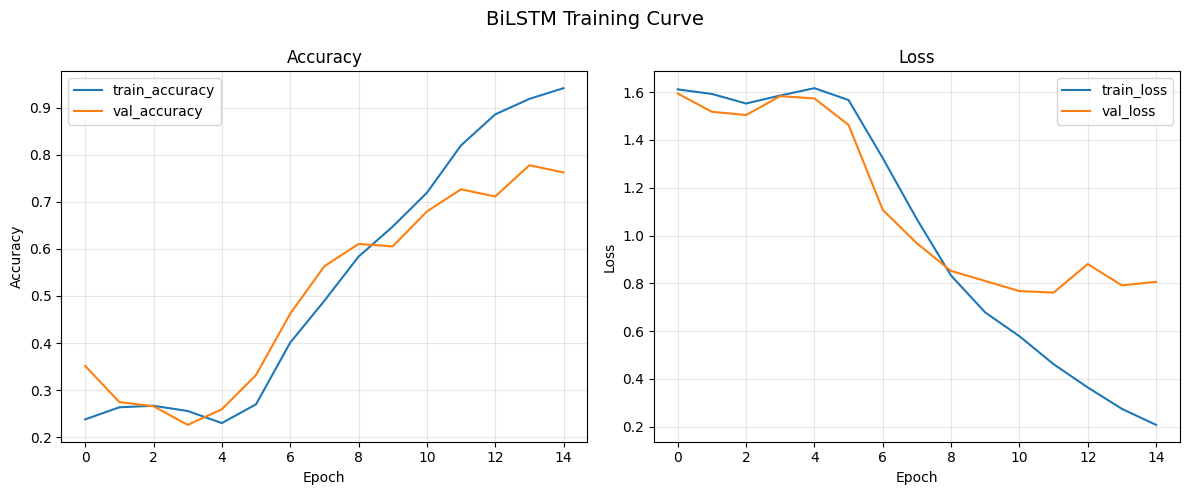

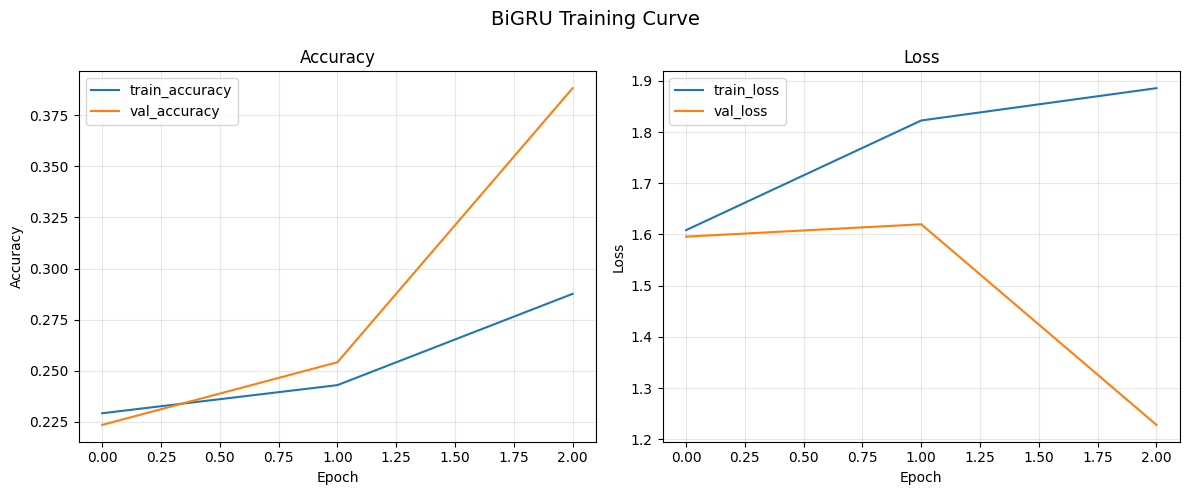

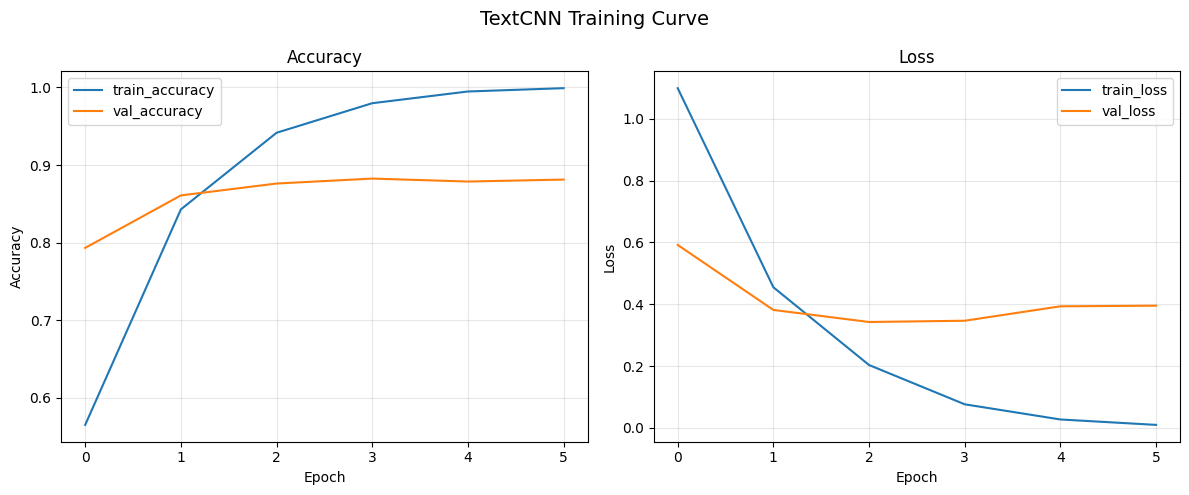

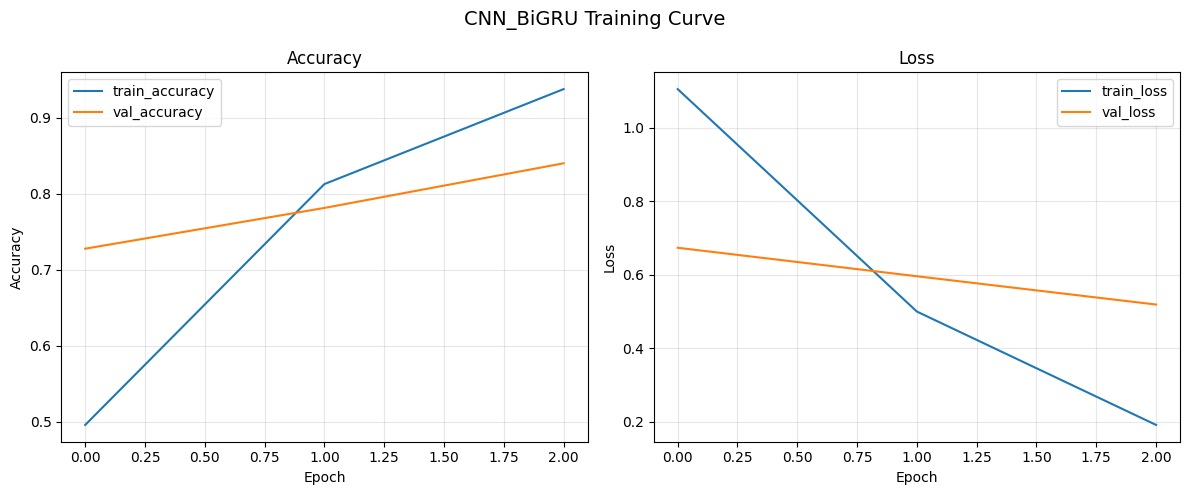

In [14]:
import os

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

for model_name, hist in histories.items():
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # Accuracy (train vs val)
    axes[0].plot(hist['accuracy'], label='train_accuracy')
    axes[0].plot(hist['val_accuracy'], label='val_accuracy')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss (train vs val)
    axes[1].plot(hist['loss'], label='train_loss')
    axes[1].plot(hist['val_loss'], label='val_loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(f'{model_name} Training Curve', fontsize=14)
    plt.tight_layout()

    fig_path = f'{FIG_DIR}/{model_name}_curve.png'
    plt.savefig(fig_path, dpi=300)
    plt.show()

# Step 3. Transformer 기반 모델 비교
- Transformer 기반 pre-trained model 대상 2차 비교군을 설정
- 계산시간 효율성을 위해 따로 분리하여 실험
- 비교 모델
1. KLUE_BERT
2. BLUE_RoBERTa
3. KoELECTRA
4. mBERT

In [3]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import tf_keras
import numpy as np
import os

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# 1. 학습 공통 설정
BATCH_SIZE = 8
EPOCHS = 5
MAX_LENGTH = 128
LEARNING_RATE = 2e-5
NUM_CLASSES = len(np.unique(y_train))

common_callbacks_2nd = [
    tf_keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=1,
        restore_best_weights=True
    ),
    tf_keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6
    )
]

def encode_texts(tokenizer, texts, max_length):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='tf'
    )

model_names = {
    'KLUE_BERT': 'klue/bert-base',
    'KLUE_RoBERTa': 'klue/roberta-base',
    'KoELECTRA': 'monologg/koelectra-base-v3-discriminator',
    'mBERT': 'bert-base-multilingual-cased'
}

In [4]:
# 모델 비교 실행

import os
SAVE_DIR = 'saved_Transformers'
os.makedirs(SAVE_DIR, exist_ok=True)

results_2nd = []
histories_2nd = {}

for model_key, model_name in model_names.items():
    print(f'\n===== {model_key} 시작 =====')

    model_dir = f'{SAVE_DIR}/{model_key}'
    history_path = f'{SAVE_DIR}/{model_key}_history.pkl'

    # ===== skip 조건 수정 =====
    if os.path.exists(f'{model_dir}/config.json') and os.path.exists(history_path):
        print(f'>>> {model_key} 이미 존재 → 로드')

        model = TFAutoModelForSequenceClassification.from_pretrained(model_dir)
        hf_tokenizer = AutoTokenizer.from_pretrained(model_dir)

        with open(history_path, 'rb') as f:
            history_dict = pickle.load(f)

        histories_2nd[model_key] = history_dict

    else:
        print(f'>>> {model_key} 학습 진행')

        hf_tokenizer = AutoTokenizer.from_pretrained(model_name)
        train_enc = encode_texts(hf_tokenizer, X_train_texts, MAX_LENGTH)
        val_enc = encode_texts(hf_tokenizer, X_val_texts, MAX_LENGTH)

        train_inputs = {k: v.numpy() for k, v in train_enc.items()}
        val_inputs = {k: v.numpy() for k, v in val_enc.items()}

        model = TFAutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=NUM_CLASSES,
            from_pt=True   # Pytorch weight을 TensorFlow 로 변환해서 로드
        )

        model.compile(
            optimizer=tf_keras.optimizers.Adam(learning_rate=2e-5),
            loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy']
        )

        history = model.fit(
            train_inputs,
            y_train,
            validation_data=(val_inputs, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=common_callbacks_2nd,
            verbose=1
        )

        history_dict = history.history
        histories_2nd[model_key] = history_dict

        # ===== 저장 방식 수정 =====
        model.save_pretrained(model_dir)
        hf_tokenizer.save_pretrained(model_dir)

        with open(history_path, 'wb') as f:
            pickle.dump(history_dict, f)

        del model
        tf.keras.backend.clear_session()
        
        import gc
        gc.collect()

    # ===== 평가 =====
    val_enc = encode_texts(hf_tokenizer, X_val_texts, MAX_LENGTH)
    val_inputs = {k: v.numpy() for k, v in val_enc.items()}

    logits = model.predict(val_inputs).logits
    y_pred = np.argmax(logits, axis=1)

    val_acc = accuracy_score(y_val, y_pred)
    val_macro_f1 = f1_score(y_val, y_pred, average='macro')

    results_2nd.append({
        'model': model_key,
        'val_accuracy': val_acc,
        'val_macro_f1': val_macro_f1
    })

    print(f'{model_key} 완료 | acc: {val_acc:.4f}, f1: {val_macro_f1:.4f}')


===== KLUE_BERT 시작 =====
>>> KLUE_BERT 이미 존재 → 로드


2026-03-18 16:30:56.973297: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-18 16:30:56.973313: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-18 16:30:56.973317: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2026-03-18 16:30:56.973330: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-18 16:30:56.973339: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

All the layers of TFBertForSequenceClassification were initialized from the model checkpoin

25/25 [==============================] - 16s 352ms/step
KLUE_BERT 완료 | acc: 0.9080, f1: 0.9018

===== KLUE_RoBERTa 시작 =====
>>> KLUE_RoBERTa 이미 존재 → 로드


All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

All the layers of TFRobertaForSequenceClassification were initialized from the model checkpoint at saved_Transformers/KLUE_RoBERTa.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaForSequenceClassification for predictions without further training.


25/25 [==============================] - 14s 361ms/step
KLUE_RoBERTa 완료 | acc: 0.8966, f1: 0.8892

===== KoELECTRA 시작 =====
>>> KoELECTRA 학습 진행


...

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5


2026-03-18 16:43:28.260939: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp_10.


555/555 [==============================] - 291s 483ms/step - loss: 0.8081 - accuracy: 0.6815 - val_loss: 0.5294 - val_accuracy: 0.8238 - lr: 2.0000e-05
Epoch 2/5
555/555 [==============================] - 251s 452ms/step - loss: 0.4411 - accuracy: 0.8434 - val_loss: 0.4023 - val_accuracy: 0.8544 - lr: 2.0000e-05
Epoch 3/5
555/555 [==============================] - 252s 453ms/step - loss: 0.3091 - accuracy: 0.8942 - val_loss: 0.3731 - val_accuracy: 0.8812 - lr: 2.0000e-05
Epoch 4/5
555/555 [==============================] - 253s 456ms/step - loss: 0.2437 - accuracy: 0.9161 - val_loss: 0.3724 - val_accuracy: 0.8851 - lr: 2.0000e-05
Epoch 5/5
25/25 [==============================] - 19s 518ms/step
mBERT 완료 | acc: 0.8851, f1: 0.8785


In [5]:
# 결과 테이블
results_2nd_df = pd.DataFrame(results_2nd).sort_values(
    by='val_macro_f1',
    ascending=False
).reset_index(drop=True)

results_2nd_df

,model,val_accuracy,val_macro_f1
0,KLUE_BERT,0.908046,0.901808
1,KoELECTRA,0.895275,0.889487
2,KLUE_RoBERTa,0.896552,0.889156
3,mBERT,0.885057,0.878483


In [6]:
import os
import pickle
import matplotlib.pyplot as plt

# 저장 위치
SAVE_DIR = 'saved_Transformers'
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

for file in os.listdir(SAVE_DIR):
    if file.endswith('_history.pkl'):
        
        model_name = file.replace('_history.pkl', '')
        history_path = os.path.join(SAVE_DIR, file)

        # history 로드
        with open(history_path, 'rb') as f:
            history = pickle.load(f)

        # figure 생성
        plt.figure(figsize=(10,4))

        # Accuracy
        plt.subplot(1,2,1)
        plt.plot(history['accuracy'], label='train_acc')
        plt.plot(history['val_accuracy'], label='val_acc')
        plt.title(f'{model_name} Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(alpha=0.3)

        # Loss
        plt.subplot(1,2,2)
        plt.plot(history['loss'], label='train_loss')
        plt.plot(history['val_loss'], label='val_loss')
        plt.title(f'{model_name} Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()

        # 저장
        save_path = os.path.join(FIG_DIR, f'{model_name}.png')
        plt.savefig(save_path, dpi=150)
        plt.close()

        print(f'저장 완료: {save_path}')

저장 완료: figures/KoELECTRA.png
저장 완료: figures/KLUE_BERT.png
저장 완료: figures/mBERT.png
저장 완료: figures/KLUE_RoBERTa.png


---

# STEP 4. 앙상블 + 웨이트 튜닝
- 학습한 두 가지 방식의 모델 중 TOP2를 뽑아 앙상블(Soft Voting)
- 2~4개까지의 모델 조합 중 가장 좋은 조합의 앙상블 모델을 찾은 뒤 웨이트를 조정하여 성능 개선

In [8]:
# 최적의 앙상블 조합 찾기

import os
import pickle
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.metrics import f1_score, accuracy_score

# ======================
# 경로
# ======================
DIR_1 = 'saved_LSTMs'
DIR_2 = 'saved_Transformers'

# ======================
# 1. 결과 불러오기
# ======================
df1 = pd.read_csv(f'{DIR_1}/results1.csv')
df2 = pd.read_csv(f'{DIR_2}/results2.csv')

# ======================
# 2. Top2 선택
# ======================
top_lstm = df1.sort_values('val_macro_f1', ascending=False).head(2)['model'].tolist()
top_trans = df2.sort_values('val_macro_f1', ascending=False).head(2)['model'].tolist()

print('LSTM Top2:', top_lstm)
print('Transformer Top2:', top_trans)

all_models = top_lstm + top_trans

# ======================
# 3. prediction 불러오기 함수
# ======================
def load_pred(model_name, model_type):
    
    if model_type == 'lstm':
        model = tf.keras.models.load_model(f'{DIR_1}/{model_name}.keras')
        pred = model.predict(X_val, verbose=0)

    else:
        model = TFAutoModelForSequenceClassification.from_pretrained(
            f'{DIR_2}/{model_name}'
        )
        tokenizer = AutoTokenizer.from_pretrained(f'{DIR_2}/{model_name}_tokenizer')

        val_enc = encode_texts(tokenizer, X_val_texts, MAX_LENGTH)
        val_inputs = {k: v.numpy() for k, v in val_enc.items()}

        logits = model.predict(val_inputs).logits
        pred = logits

    return pred


# ======================
# 4. 모든 모델 prediction 미리 계산
# ======================
pred_dict = {}

for m in top_lstm:
    pred_dict[m] = load_pred(m, 'lstm')

for m in top_trans:
    pred_dict[m] = load_pred(m, 'trans')


# ======================
# 5. 조합 평가
# ======================
results = []

for r in range(2, len(all_models)+1):
    for combo in combinations(all_models, r):

        preds = [pred_dict[m] for m in combo]

        # 평균 앙상블
        avg_pred = np.mean(preds, axis=0)
        y_pred = np.argmax(avg_pred, axis=1)

        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')

        results.append({
            'models': combo,
            'n_models': r,
            'accuracy': acc,
            'macro_f1': f1
        })

# ======================
# 6. 결과 정리
# ======================
ensemble_df = pd.DataFrame(results)
ensemble_df = ensemble_df.sort_values('macro_f1', ascending=False)

print('\n===== BEST ENSEMBLE =====')
print(ensemble_df.head(10))

# 저장
ensemble_df.to_csv('ensemble_search_results.csv', index=False)

LSTM Top2: ['TextCNN', 'BiLSTM']
Transformer Top2: ['KLUE_BERT']


Some layers from the model checkpoint at saved_Transformers/KLUE_BERT were not used when initializing TFBertForSequenceClassification: ['dropout_37']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at saved_Transformers/KLUE_BERT.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


25/25 [==============================] - 16s 376ms/step

===== BEST ENSEMBLE =====
                         models  n_models  accuracy  macro_f1
3  (TextCNN, BiLSTM, KLUE_BERT)         3  0.918263  0.912936
1          (TextCNN, KLUE_BERT)         2  0.914432  0.908918
2           (BiLSTM, KLUE_BERT)         2  0.909323  0.902661
0             (TextCNN, BiLSTM)         2  0.871009  0.863096


In [9]:
# 웨이트 튜닝
import ast
import numpy as np
import pandas as pd
from itertools import product
from sklearn.metrics import f1_score, accuracy_score

# =========================
# 1. best ensemble 조합 가져오기
# =========================
best_combo = ensemble_df.iloc[0]['models']

if isinstance(best_combo, str):
    best_combo = ast.literal_eval(best_combo)

print('Best combo:', best_combo)


# =========================
# 2. logits/probability 통일
# =========================
def softmax_np(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def to_probability(pred):
    row_sums = pred.sum(axis=1)

    if np.all(pred >= 0) and np.allclose(row_sums, 1.0, atol=1e-3):
        return pred

    return softmax_np(pred)


# =========================
# 3. best 조합의 prediction만 모으기
# =========================
combo_preds = {}
for model_name in best_combo:
    combo_preds[model_name] = to_probability(pred_dict[model_name])

print('Models for weight tuning:', list(combo_preds.keys()))


# =========================
# 4. weight tuning 함수
# =========================
def tune_weights(combo_preds, y_true, step=0.1):
    model_names = list(combo_preds.keys())
    n_models = len(model_names)

    weight_candidates = np.arange(0, 1 + step, step)
    results = []

    for ws in product(weight_candidates, repeat=n_models):
        if not np.isclose(sum(ws), 1.0):
            continue

        ensemble_pred = np.zeros_like(combo_preds[model_names[0]])

        for w, model_name in zip(ws, model_names):
            ensemble_pred += w * combo_preds[model_name]

        y_pred = np.argmax(ensemble_pred, axis=1)

        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average='macro')

        results.append({
            'models': model_names,
            'weights': ws,
            'accuracy': acc,
            'macro_f1': macro_f1
        })

    results_df = pd.DataFrame(results).sort_values(
        by='macro_f1',
        ascending=False
    ).reset_index(drop=True)

    return results_df


# =========================
# 5. coarse search
# =========================
weight_search_df = tune_weights(combo_preds, y_val, step=0.1)

print('\n===== TOP 10 WEIGHT COMBINATIONS =====')
print(weight_search_df.head(10))


# =========================
# 6. best weight 출력
# =========================
best_weights = weight_search_df.iloc[0]['weights']
best_f1 = weight_search_df.iloc[0]['macro_f1']
best_acc = weight_search_df.iloc[0]['accuracy']

print('\n===== BEST WEIGHT RESULT =====')
print('Best combo:', best_combo)
print('Best weights:', best_weights)
print('Best macro_f1:', best_f1)
print('Best accuracy:', best_acc)


# =========================
# 7. 결과 저장
# =========================
weight_search_df.to_csv('best_combo_weight_tuning.csv', index=False)

Best combo: ('TextCNN', 'BiLSTM', 'KLUE_BERT')
Models for weight tuning: ['TextCNN', 'BiLSTM', 'KLUE_BERT']

===== TOP 10 WEIGHT COMBINATIONS =====
                         models  \
0  [TextCNN, BiLSTM, KLUE_BERT]   
1  [TextCNN, BiLSTM, KLUE_BERT]   
2  [TextCNN, BiLSTM, KLUE_BERT]   
3  [TextCNN, BiLSTM, KLUE_BERT]   
4  [TextCNN, BiLSTM, KLUE_BERT]   
5  [TextCNN, BiLSTM, KLUE_BERT]   
6  [TextCNN, BiLSTM, KLUE_BERT]   
7  [TextCNN, BiLSTM, KLUE_BERT]   
8  [TextCNN, BiLSTM, KLUE_BERT]   
9  [TextCNN, BiLSTM, KLUE_BERT]   

                                          weights  accuracy  macro_f1  
0                  (0.2, 0.2, 0.6000000000000001)  0.923372  0.918421  
1                 (0.30000000000000004, 0.2, 0.5)  0.922095  0.917312  
2                                 (0.4, 0.1, 0.5)  0.920817  0.916516  
3                  (0.4, 0.0, 0.6000000000000001)  0.920817  0.916337  
4                 (0.2, 0.30000000000000004, 0.5)  0.920817  0.916230  
5                  (0.2, 0.1, 0.70

---

# Step 5. 테스트 데이터 예측하기

In [34]:
# ===== 예측 생성 셀 =====

import os
import gc
import ast
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

LSTM_DIR = 'saved_LSTMs'
TRANS_DIR = 'saved_Transformers'
ART_DIR = 'artifacts'

TEST_PATH = 'data/test.csv'
WEIGHT_PATH = 'best_combo_weight_tuning.csv'

def softmax_np(x):
    x = x - np.max(x, axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=1, keepdims=True)

# ===== best ensemble 정보 =====
weight_df = pd.read_csv(WEIGHT_PATH)
best_row = weight_df.iloc[0]

best_combo = ast.literal_eval(best_row['models'])
best_weights = ast.literal_eval(best_row['weights'])

print('Best combo:', best_combo)
print('Best weights:', best_weights)

# ===== test 로드 =====
test_data = pd.read_csv(TEST_PATH)

test_ids = test_data['idx'].tolist()
test_texts_raw = test_data[text_col].tolist()

# ===== 공통 전처리 =====
cleaned_texts = [clean_korean_text(t) for t in test_texts_raw]

# ===== LSTM 입력 =====
tokenized_texts = [tokenize_korean(t) for t in cleaned_texts]

with open(os.path.join(ART_DIR, 'lstm_tokenizer.pkl'), 'rb') as f:
    lstm_tokenizer = pickle.load(f)

if not hasattr(lstm_tokenizer, 'texts_to_sequences'):
    raise TypeError(
        f'lstm_tokenizer.pkl이 Keras Tokenizer가 아닙니다. 현재 타입: {type(lstm_tokenizer)}'
    )

X_test_lstm = pad_sequences(
    lstm_tokenizer.texts_to_sequences(tokenized_texts),
    maxlen=150,
    padding='post',
    truncating='post'
)

# ===== Transformer 입력 =====
X_test_texts = cleaned_texts

# ===== 모델별 예측 =====
all_probs = []

for model_name, weight in zip(best_combo, best_weights):
    print(f'Predict: {model_name} | weight={weight}')

    lstm_path = os.path.join(LSTM_DIR, f'{model_name}.keras')
    trans_path = os.path.join(TRANS_DIR, model_name)

    # LSTM / CNN 계열
    if os.path.exists(lstm_path):
        model = keras.models.load_model(lstm_path)
        probs = model.predict(X_test_lstm, batch_size=32, verbose=1)

    # Transformer 계열
    elif os.path.isdir(trans_path):
        hf_tokenizer = AutoTokenizer.from_pretrained(trans_path)
        model = TFAutoModelForSequenceClassification.from_pretrained(trans_path)

        enc = hf_tokenizer(
            X_test_texts,
            padding='max_length',
            truncation=True,
            max_length=128,
            return_tensors='tf'
        )
        inputs = {k: v.numpy() for k, v in enc.items()}
        logits = model.predict(inputs, batch_size=8, verbose=1).logits
        probs = softmax_np(logits)

        del hf_tokenizer, enc, inputs, logits

    else:
        raise FileNotFoundError(f'모델을 찾을 수 없습니다: {model_name}')

    all_probs.append(weight * probs)

    del model
    gc.collect()
    tf.keras.backend.clear_session()

# ===== 앙상블 최종 예측 =====
ensemble_probs = np.sum(all_probs, axis=0)
pred_indices = np.argmax(ensemble_probs, axis=1)

print('Prediction done:', pred_indices.shape)

Best combo: ['TextCNN', 'BiLSTM', 'KLUE_BERT']
Best weights: (0.2, 0.2, 0.6000000000000001)
Predict: TextCNN | weight=0.2
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Predict: BiLSTM | weight=0.2
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
Predict: KLUE_BERT | weight=0.6000000000000001


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at saved_Transformers/KLUE_BERT.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


63/63 [==============================] - 16s 141ms/step
Prediction done: (500,)


In [35]:
# ===== 제출 파일 생성 셀 =====

submission = pd.DataFrame({
    'idx': test_ids,
    'class': pred_indices.astype(int)
})

save_path = 'submission_ensemble.csv'
submission.to_csv(save_path, index=False, encoding='utf-8-sig')

print(submission.head())
print(submission.shape)
print(f'저장 완료: {save_path}')

     idx  class
0  t_000      1
1  t_001      2
2  t_002      2
3  t_003      3
4  t_004      3
(500, 2)
저장 완료: submission_ensemble.csv


---

# 그 외 시도들

In [44]:
# ===== Transformer TOP1 자동 선택 → 단일 모델 제출 =====

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

# ===== 설정 =====
TRANS_DIR = 'saved_Transformers'
RESULT_PATH = os.path.join(TRANS_DIR, 'results2.csv')
TEST_PATH = 'data/test.csv'
SAVE_PATH = 'submission_transformer_top1.csv'

# ===== results2.csv 로드 =====
if not os.path.exists(RESULT_PATH):
    raise FileNotFoundError('results2.csv 없음 → 먼저 2차 비교군 실행 필요')

results_df = pd.read_csv(RESULT_PATH)

if 'val_macro_f1' not in results_df.columns:
    raise ValueError('results2.csv에 val_macro_f1 컬럼 없음')

# ===== TOP1 선택 =====
results_df = results_df.sort_values(by='val_macro_f1', ascending=False)
MODEL_NAME = results_df.iloc[0]['model']

print(f'선택된 TOP1 모델: {MODEL_NAME}')

# ===== test 로드 =====
test_data = pd.read_csv(TEST_PATH)

# id 컬럼 탐색
if 'idx' in test_data.columns:
    id_col = 'idx'
elif 'file_name' in test_data.columns:
    id_col = 'file_name'
elif 'id' in test_data.columns:
    id_col = 'id'
else:
    raise ValueError(f'id 컬럼 없음: {test_data.columns.tolist()}')

# text 컬럼 탐색
if 'conversation' in test_data.columns:
    text_col = 'conversation'
elif 'text' in test_data.columns:
    text_col = 'text'
else:
    raise ValueError(f'text 컬럼 없음: {test_data.columns.tolist()}')

test_ids = test_data[id_col].values
test_texts = test_data[text_col].astype(str).tolist()

# ===== 모델 로드 =====
model_path = os.path.join(TRANS_DIR, MODEL_NAME)

if not os.path.isdir(model_path):
    raise FileNotFoundError(f'모델 폴더 없음: {model_path}')

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = TFAutoModelForSequenceClassification.from_pretrained(model_path)

# ===== 토크나이즈 =====
enc = tokenizer(
    test_texts,
    padding='max_length',
    truncation=True,
    max_length=128,
    return_tensors='tf'
)

inputs = {k: v.numpy() for k, v in enc.items()}

# ===== 예측 =====
logits = model.predict(inputs, batch_size=8, verbose=1).logits
preds = np.argmax(logits, axis=1).astype(int)

# ===== 제출 파일 생성 =====
submission = pd.DataFrame({
    'idx': test_ids,
    'class': preds
})

submission.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')

print('\n===== DONE =====')
print(submission.head())
print(submission.shape)
print(f'저장 완료: {SAVE_PATH}')

# ===== 메모리 정리 =====
del model, tokenizer, enc, inputs, logits
gc.collect()
tf.keras.backend.clear_session()

선택된 TOP1 모델: KLUE_BERT


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at saved_Transformers/KLUE_BERT.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


63/63 [==============================] - 16s 161ms/step

===== DONE =====
     idx  class
0  t_000      1
1  t_001      2
2  t_002      2
3  t_003      3
4  t_004      3
(500, 2)
저장 완료: submission_transformer_top1.csv
